In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = [
    "background", "yes", "no", "up", "down", "left", 
    "right", "on", "off", "stop", "go", "unknown"
]

def analyze_experiment_pair(base_dir, preprocessing, augmentation, seeds, cm_seed, layers=2, dropout=0.1, learning_rate=0.001, method="two_stage"):
    """
    Analyzes a specific preprocessing + augmentation pair across multiple seeds.
    Calculates mean/std metrics, plots learning curves, plots a confusion matrix,
    and returns a dictionary with the summary of metrics for DataFrame aggregation.
    """
    
    print(f"\n{'='*80}")
    print(f"ANALYSIS: Method: {method} | Preprocessing: {preprocessing} | Augmentation: {augmentation} | Layers: {layers} | Dropout: {dropout} | LR: {learning_rate}")
    print(f"{'='*80}")

    all_histories = []
    all_metrics = []
    cm_df = None
    
    exp_summary = {
        'method': method,
        'Preprocessing': preprocessing,
        'Augmentation': augmentation,
        'Layers': layers,
        'Dropout': dropout,
        'Learning Rate': learning_rate
    }
    
    # 1. DATA COLLECTION
    for seed in seeds:
        exp_name = f"{method}_lstm_preprocessing_{preprocessing}_aug_{augmentation}_seed_{seed}_layers_{layers}_dropout_{dropout}_lr_{learning_rate}"
        exp_dir = os.path.join(base_dir, exp_name)
        
        if not os.path.exists(exp_dir):
            print(f"[Warning] Folder not found: {exp_dir}")
            continue
            
        history_path = os.path.join(exp_dir, "training_history.csv")
        if method == "two_stage":
        
            metrics_path = os.path.join(exp_dir, "test_metrics_two_stage_final_12class.csv")
            cm_path = os.path.join(exp_dir, "test_confusion_matrix_final_12class.csv")
        elif method == "single_stage":
            metrics_path = os.path.join(exp_dir, "test_metrics_model_space.csv")
            cm_path = os.path.join(exp_dir, "test_confusion_matrix_model_space.csv")
        else:
            raise ValueError("Invalid method specified. Use 'two_stage' or 'single_stage'.")
        
        if os.path.exists(history_path):
            df_hist = pd.read_csv(history_path)
            df_hist['seed'] = seed
            all_histories.append(df_hist)
            
        if os.path.exists(metrics_path):
            df_met = pd.read_csv(metrics_path)
            all_metrics.append(df_met)
            
        if seed == cm_seed and os.path.exists(cm_path):
            cm_df = pd.read_csv(cm_path)

    if not all_metrics or not all_histories:
        print("Not enough data found to perform analysis. Check your paths.\n")
        return None

    # 2. METRICS AGGREGATION (Mean and Std)
    df_all_metrics = pd.concat(all_metrics, ignore_index=True)
    
    
    if method == "two_stage":
        target_cols = [
            'final_12class.macro_f1', 
            'final_12class.balanced_acc', 
            'final_12class.overall_acc'
        ]
    else:
        target_cols = [
            'macro_f1', 
            'balanced_acc', 
            'overall_acc'
        ]

    
    print("--- FINAL TEST METRICS (12 CLASSES) ---")
    for col in target_cols:
        if col in df_all_metrics.columns:
            mean_val = df_all_metrics[col].mean()
            std_val = df_all_metrics[col].std()
            if method == "two_stage":
                metric_name = col.split('.')[1]
            else:
                metric_name = col
            
            print(f"{metric_name:>15}: {mean_val:.4f} ± {std_val:.4f}")
            exp_summary[metric_name] = f"{mean_val:.4f} ± {std_val:.4f}"

    # 3. PLOTTING: Figure setup
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"LSTM: {preprocessing.upper()} + {augmentation.upper()}", fontsize=16)

    # --- PLOT A: Learning Curve (Mean + Std Envelope) ---
    df_all_hist = pd.concat(all_histories, ignore_index=True)
    
    epoch_stats = df_all_hist.groupby('epoch').agg(
        loss_mean=('val_loss', 'mean'),
        loss_std=('val_loss', 'std'),
        f1_mean=('val_macro_f1', 'mean'),
        f1_std=('val_macro_f1', 'std')
    ).reset_index()

    ax1 = axes[0]
    epochs = epoch_stats['epoch']
    
    ax1.plot(epochs, epoch_stats['f1_mean'], color='blue', label='Val Macro F1 (Mean)', linewidth=2)
    ax1.fill_between(
        epochs, 
        epoch_stats['f1_mean'] - epoch_stats['f1_std'], 
        epoch_stats['f1_mean'] + epoch_stats['f1_std'], 
        color='blue', alpha=0.2, label='F1 Std Dev'
    )
    
    ax1.set_title("Validation Learning Curve")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Macro F1-Score")
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    # --- PLOT B: Confusion Matrix ---
    ax2 = axes[1]
    if cm_df is not None:
        cm_matrix = cm_df.drop(columns=['true_label']).values
        sns.heatmap(
            cm_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2
        )
        ax2.set_title(f"Confusion Matrix (Seed: {cm_seed})")
        ax2.set_xlabel("Predicted Label")
        ax2.set_ylabel("True Label")
        ax2.tick_params(axis='x', rotation=45)
    else:
        ax2.text(0.5, 0.5, f"CM data not found for seed {cm_seed}", ha='center', va='center')
        ax2.axis('off')

    plt.tight_layout()
    plt.show()
    
    return exp_summary


ANALYSIS: Method: two_stage | Preprocessing: mel_spectrogram | Augmentation: spec_augment | Layers: 2 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.7999 ± 0.0122
   balanced_acc: 0.8461 ± 0.0124
    overall_acc: 0.8451 ± 0.0125


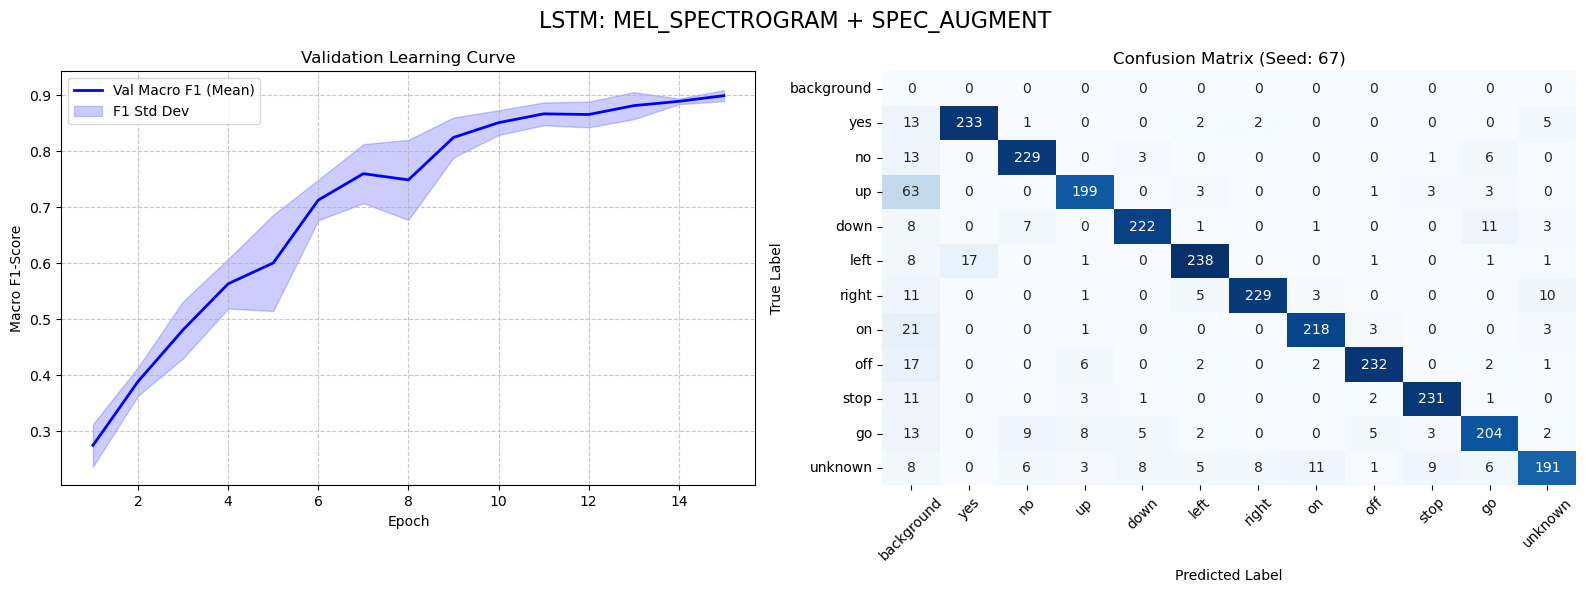


ANALYSIS: Method: two_stage | Preprocessing: mel_spectrogram | Augmentation: speed_perturbation | Layers: 2 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.7929 ± 0.0066
   balanced_acc: 0.8346 ± 0.0060
    overall_acc: 0.8339 ± 0.0058


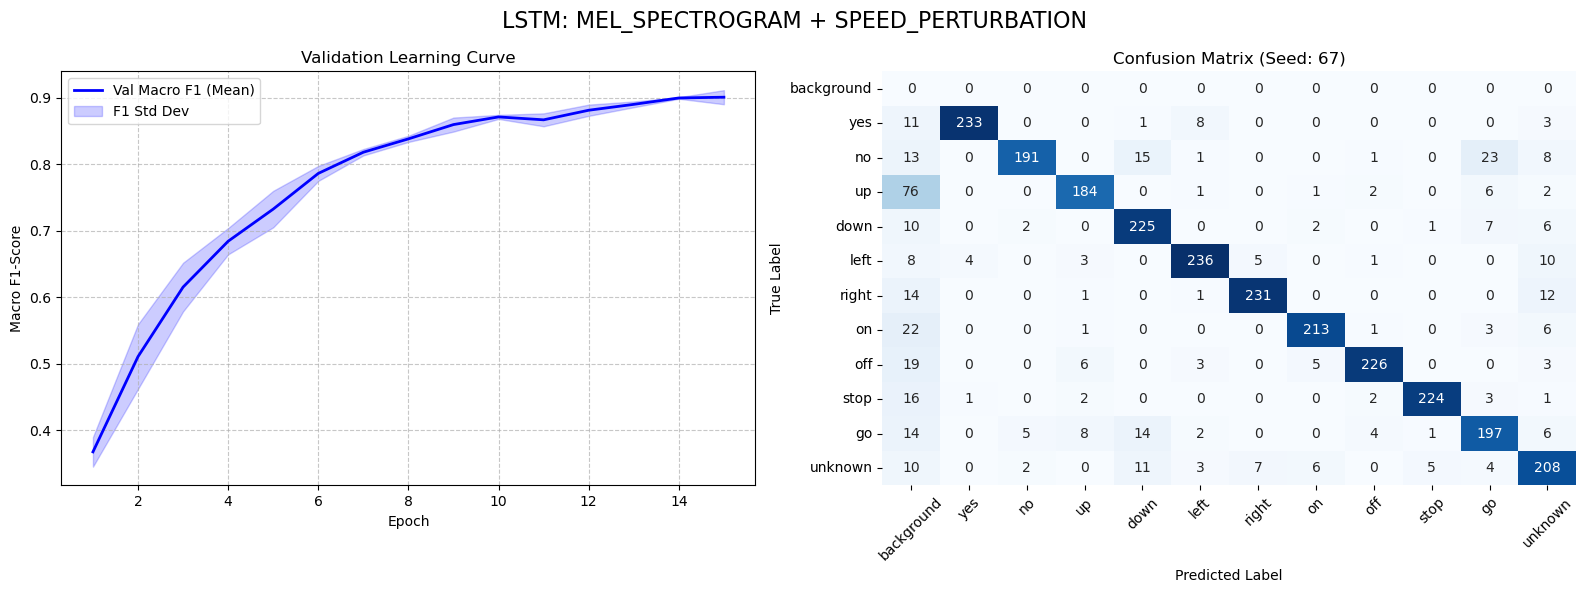


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 2 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8063 ± 0.0039
   balanced_acc: 0.8499 ± 0.0038
    overall_acc: 0.8495 ± 0.0034


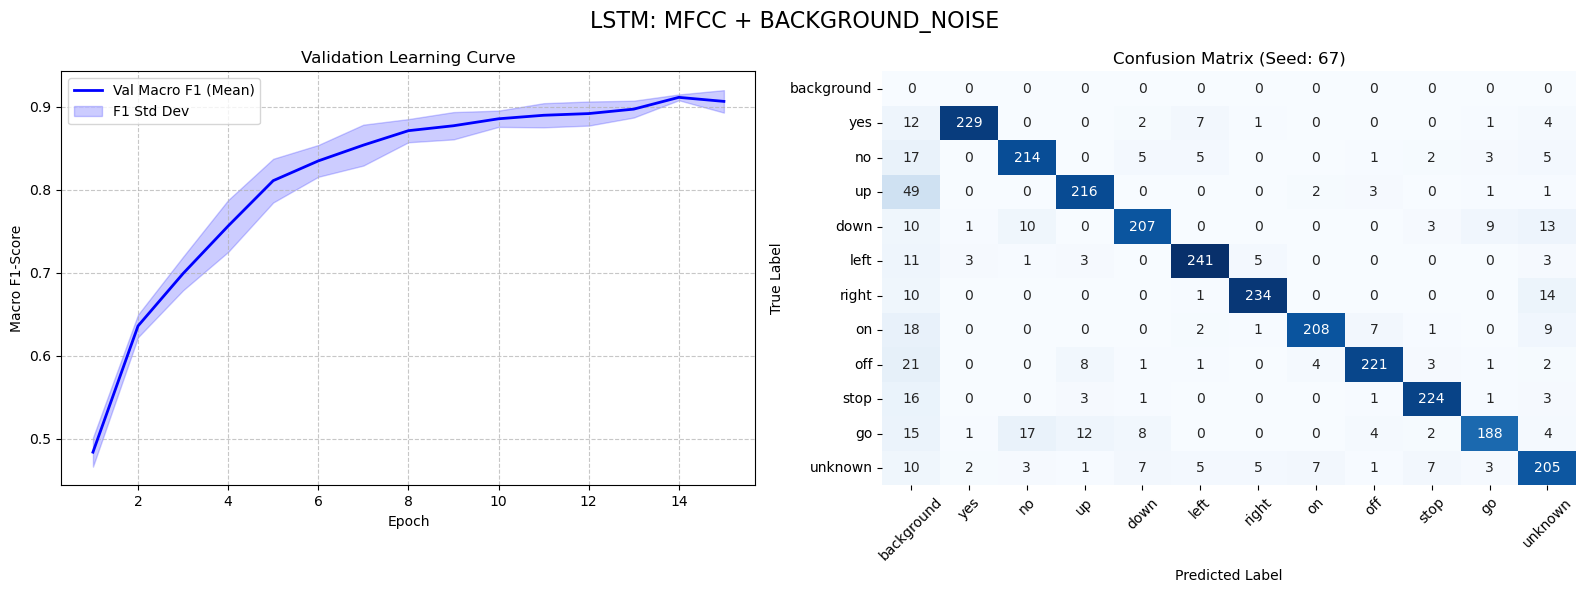


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: none | Layers: 2 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8037 ± 0.0060
   balanced_acc: 0.8485 ± 0.0071
    overall_acc: 0.8478 ± 0.0069


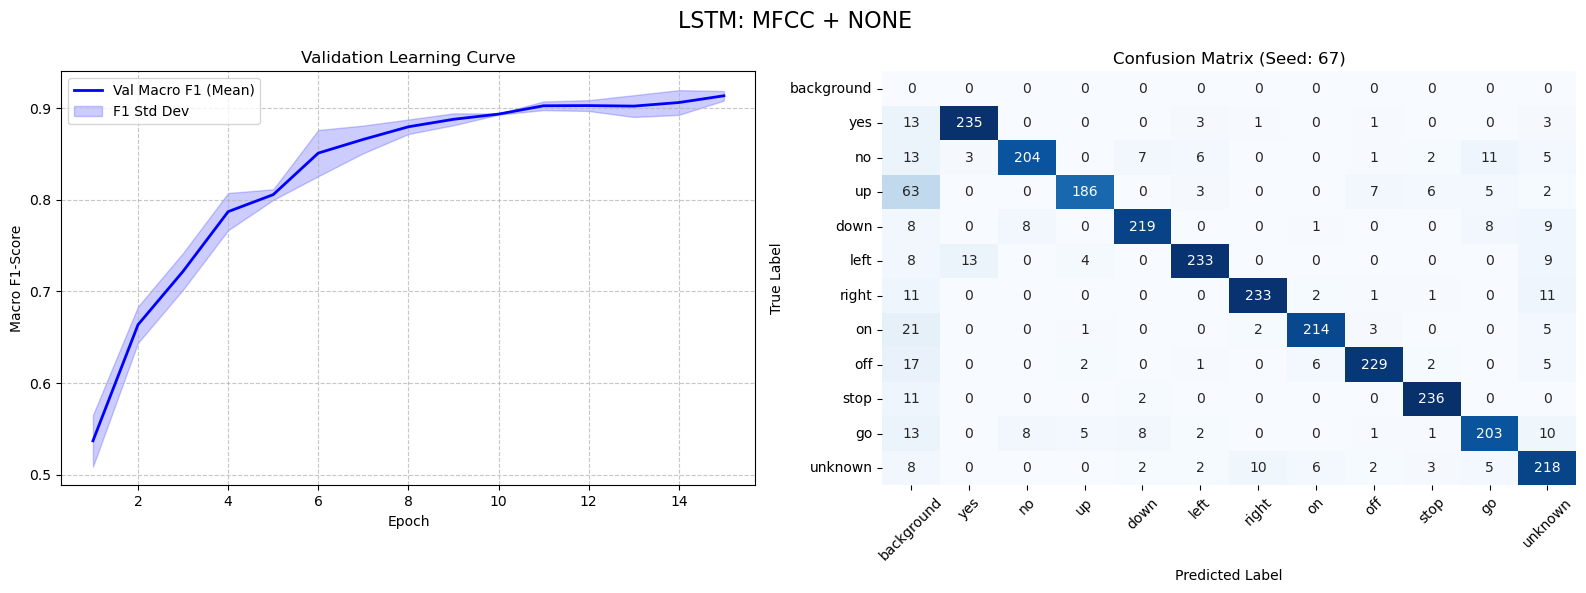


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: speed_perturbation | Layers: 2 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8028 ± 0.0083
   balanced_acc: 0.8446 ± 0.0078
    overall_acc: 0.8435 ± 0.0080


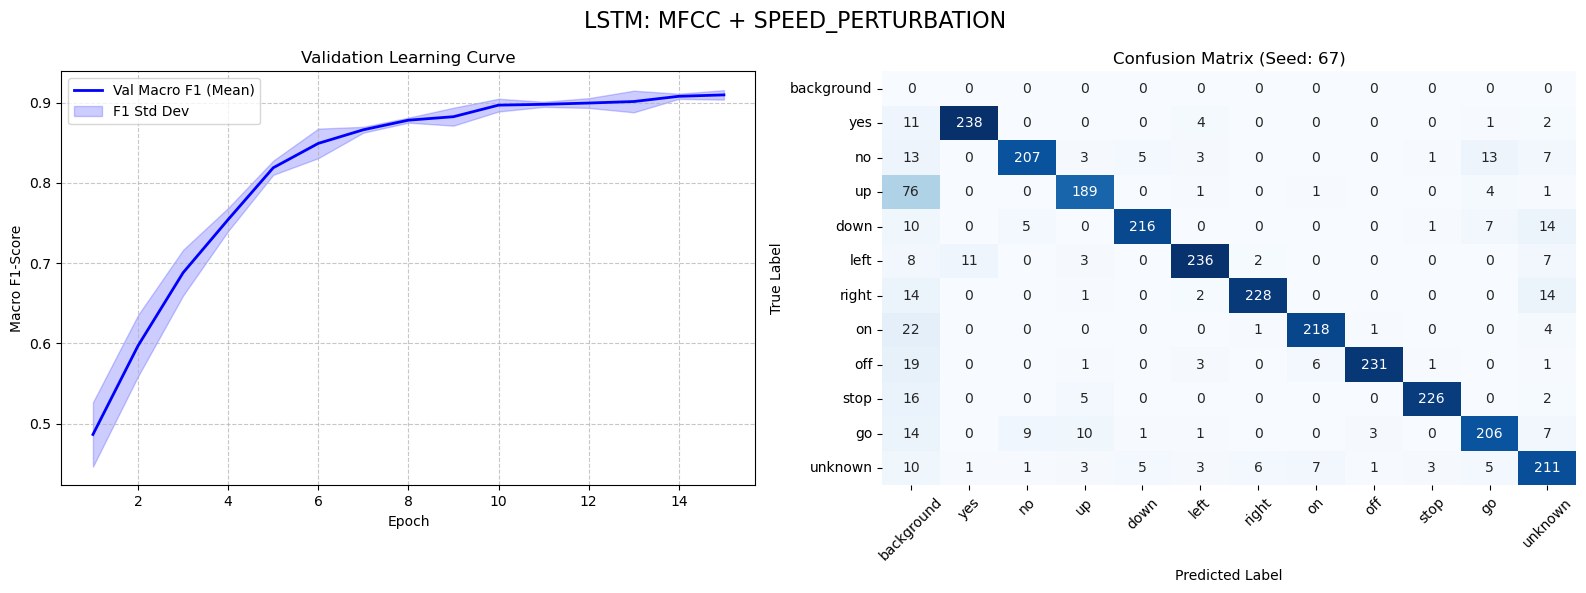


ANALYSIS: Method: two_stage | Preprocessing: raw | Augmentation: background_noise | Layers: 2 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.7322 ± 0.0252
   balanced_acc: 0.7715 ± 0.0275
    overall_acc: 0.7707 ± 0.0276


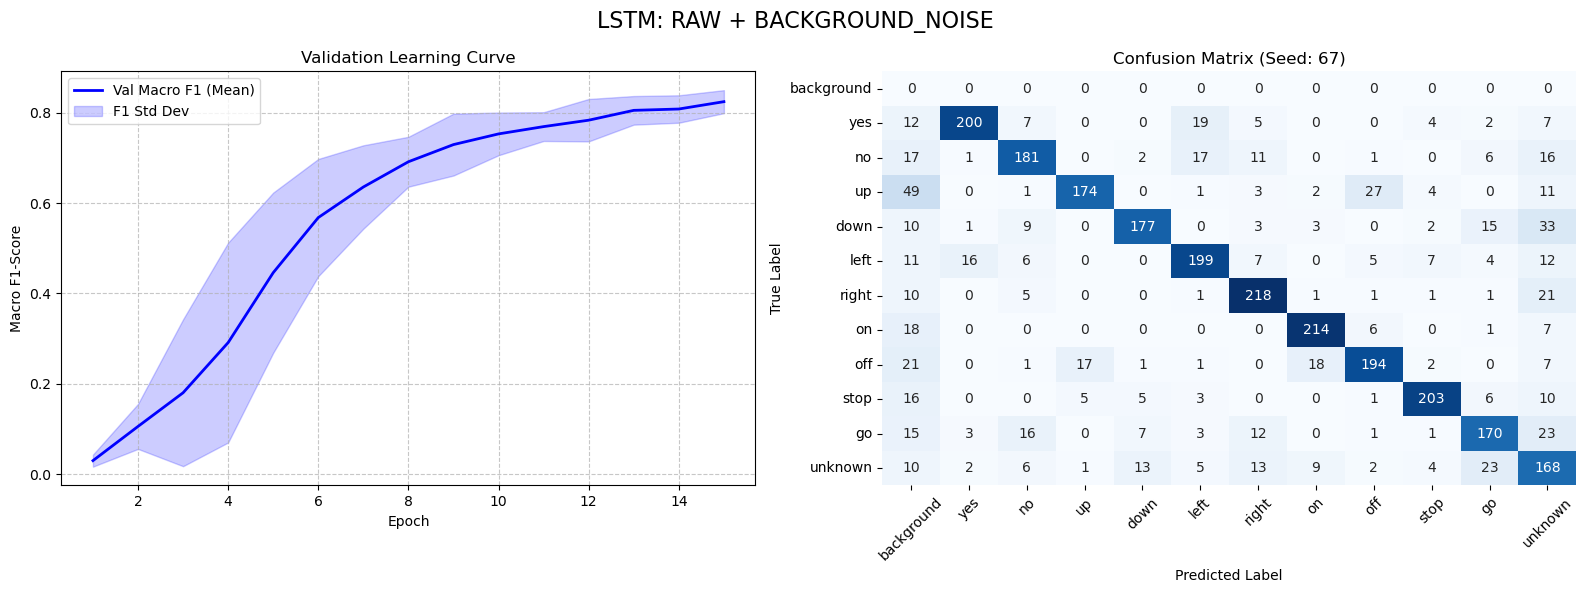



=== SUMMARY OF ALL EXPERIMENTS ===


,method,Preprocessing,Augmentation,Layers,Dropout,Learning Rate,macro_f1,balanced_acc,overall_acc
0,two_stage,mel_spectrogram,spec_augment,2,0.1,0.001,0.7999 ± 0.0122,0.8461 ± 0.0124,0.8451 ± 0.0125
1,two_stage,mel_spectrogram,speed_perturbation,2,0.1,0.001,0.7929 ± 0.0066,0.8346 ± 0.0060,0.8339 ± 0.0058
2,two_stage,mfcc,background_noise,2,0.1,0.001,0.8063 ± 0.0039,0.8499 ± 0.0038,0.8495 ± 0.0034
3,two_stage,mfcc,none,2,0.1,0.001,0.8037 ± 0.0060,0.8485 ± 0.0071,0.8478 ± 0.0069
4,two_stage,mfcc,speed_perturbation,2,0.1,0.001,0.8028 ± 0.0083,0.8446 ± 0.0078,0.8435 ± 0.0080
5,two_stage,raw,background_noise,2,0.1,0.001,0.7322 ± 0.0252,0.7715 ± 0.0275,0.7707 ± 0.0276


In [2]:
RESULTS_DIR = "../experiments_lstm/phase1" 

SEEDS = [67, 167, 267] 

pairs_to_evaluate = [
    {"prep": "mel_spectrogram", "aug": "spec_augment"},
    {"prep": "mel_spectrogram", "aug": "speed_perturbation"},
    {"prep": "mfcc", "aug": "background_noise"},
    {"prep": "mfcc", "aug": "none"},
    {"prep": "mfcc", "aug": "speed_perturbation"},
    {"prep": "raw", "aug": "background_noise"},
]

summary_results = []

for pair in pairs_to_evaluate:
    summary = analyze_experiment_pair(
        base_dir=RESULTS_DIR,
        preprocessing=pair["prep"],
        augmentation=pair["aug"],
        seeds=SEEDS,
        cm_seed=67,
        layers=2,
        dropout=0.1,
        learning_rate=0.001
    )
    
    if summary is not None:
        summary_results.append(summary)
        
        
summary_df = pd.DataFrame(summary_results)
print("\n\n=== SUMMARY OF ALL EXPERIMENTS ===")
summary_df

# best prep: mfcc, augmentation: background_noise


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 1 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.7230 ± 0.0076
   balanced_acc: 0.7619 ± 0.0053
    overall_acc: 0.7610 ± 0.0055


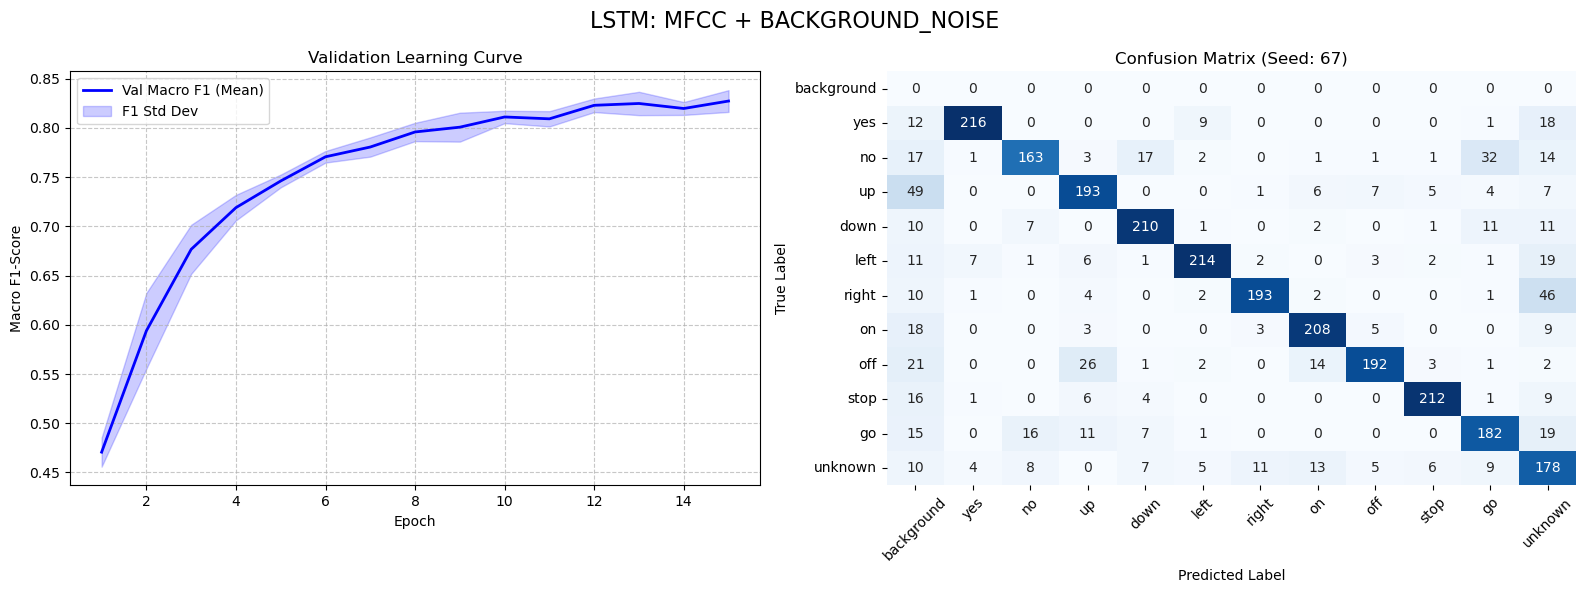


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 2 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8063 ± 0.0039
   balanced_acc: 0.8499 ± 0.0038
    overall_acc: 0.8495 ± 0.0034


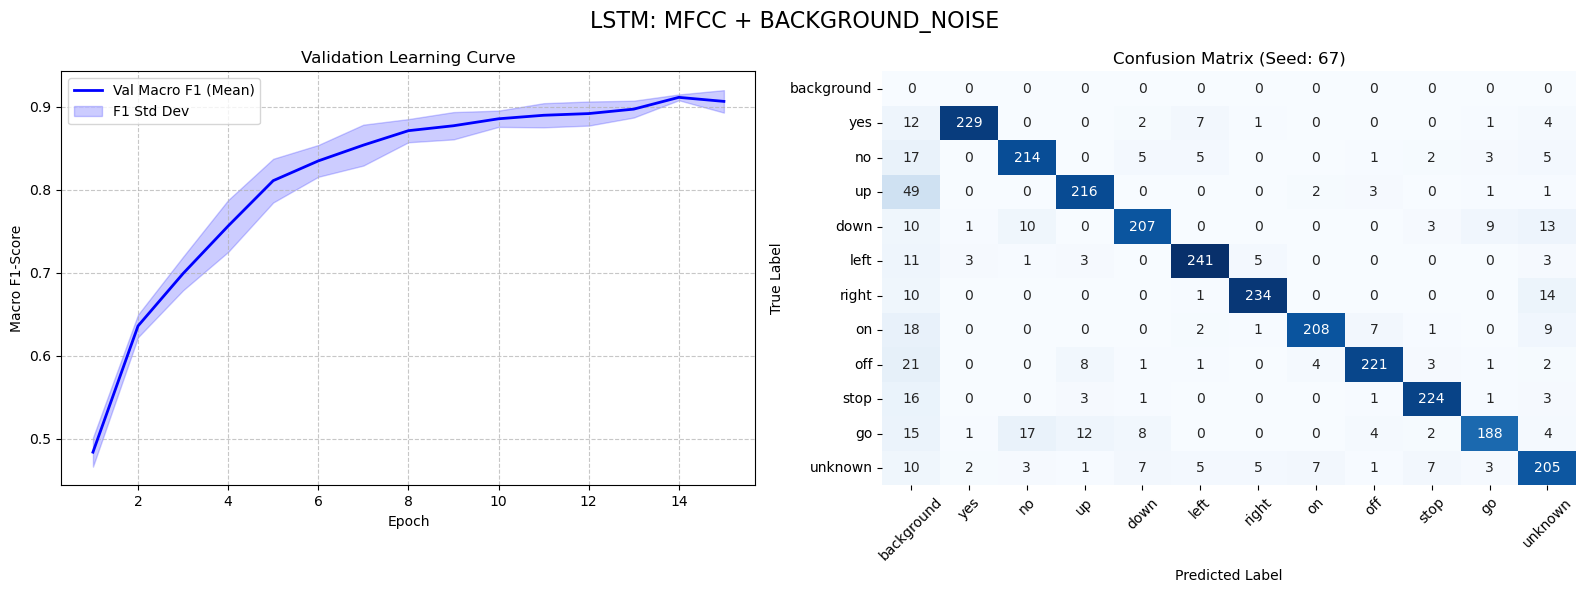


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 3 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8183 ± 0.0095
   balanced_acc: 0.8627 ± 0.0107
    overall_acc: 0.8621 ± 0.0109


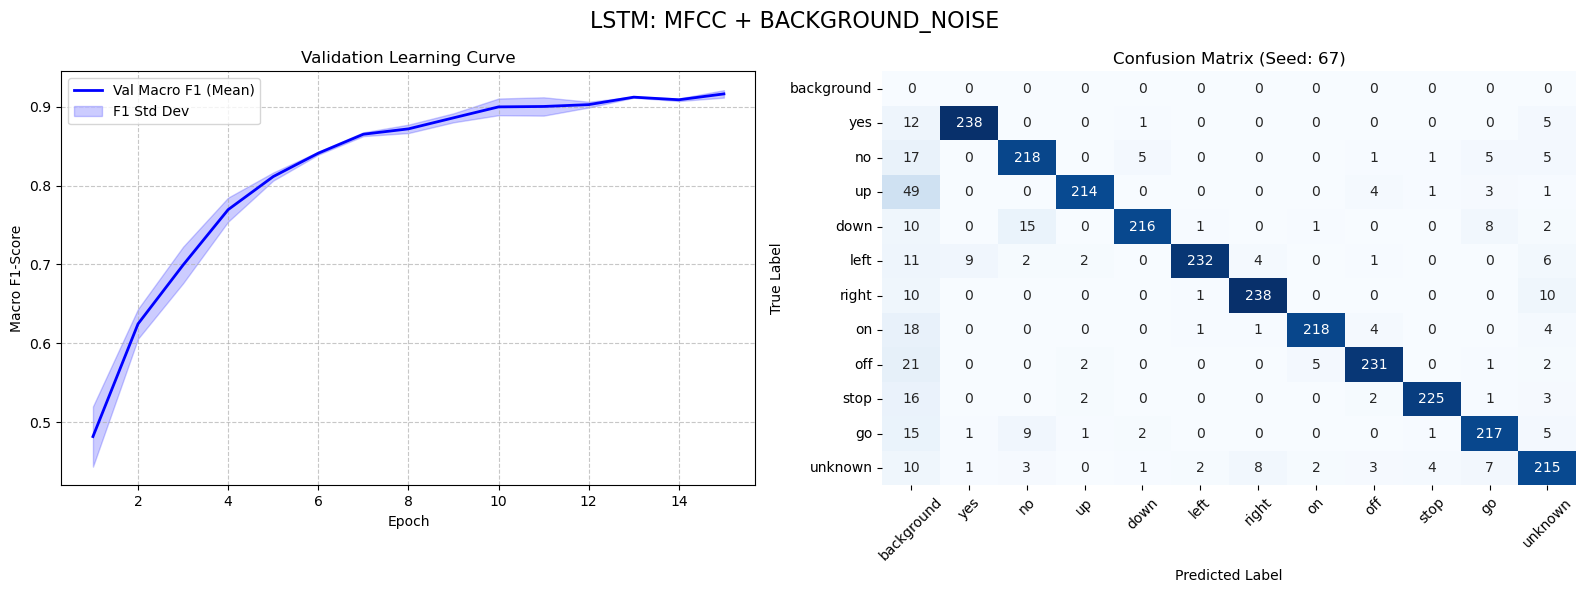

,method,Preprocessing,Augmentation,Layers,Dropout,Learning Rate,macro_f1,balanced_acc,overall_acc
0,two_stage,mfcc,background_noise,1,0.1,0.001,0.7230 ± 0.0076,0.7619 ± 0.0053,0.7610 ± 0.0055
1,two_stage,mfcc,background_noise,2,0.1,0.001,0.8063 ± 0.0039,0.8499 ± 0.0038,0.8495 ± 0.0034
2,two_stage,mfcc,background_noise,3,0.1,0.001,0.8183 ± 0.0095,0.8627 ± 0.0107,0.8621 ± 0.0109


In [3]:
RESULTS_DIR = "../experiments_lstm/phase2/layer_num" 

SEEDS = [67, 167, 267] 

layers_num = [1,2,3]

summary_results_layers = []

for layers in layers_num:
    summary = analyze_experiment_pair(
        base_dir=RESULTS_DIR,
        preprocessing="mfcc",
        augmentation="background_noise",
        seeds=SEEDS,
        cm_seed=67,
        layers=layers,
        dropout=0.1,
        learning_rate=0.001
    )
    if summary is not None:
        summary_results_layers.append(summary)
        
summary_df_layers = pd.DataFrame(summary_results_layers)

summary_df_layers

# best layers num = 3, best prep: mfcc,  augmentation: background_noise


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 3 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8183 ± 0.0095
   balanced_acc: 0.8627 ± 0.0107
    overall_acc: 0.8621 ± 0.0109


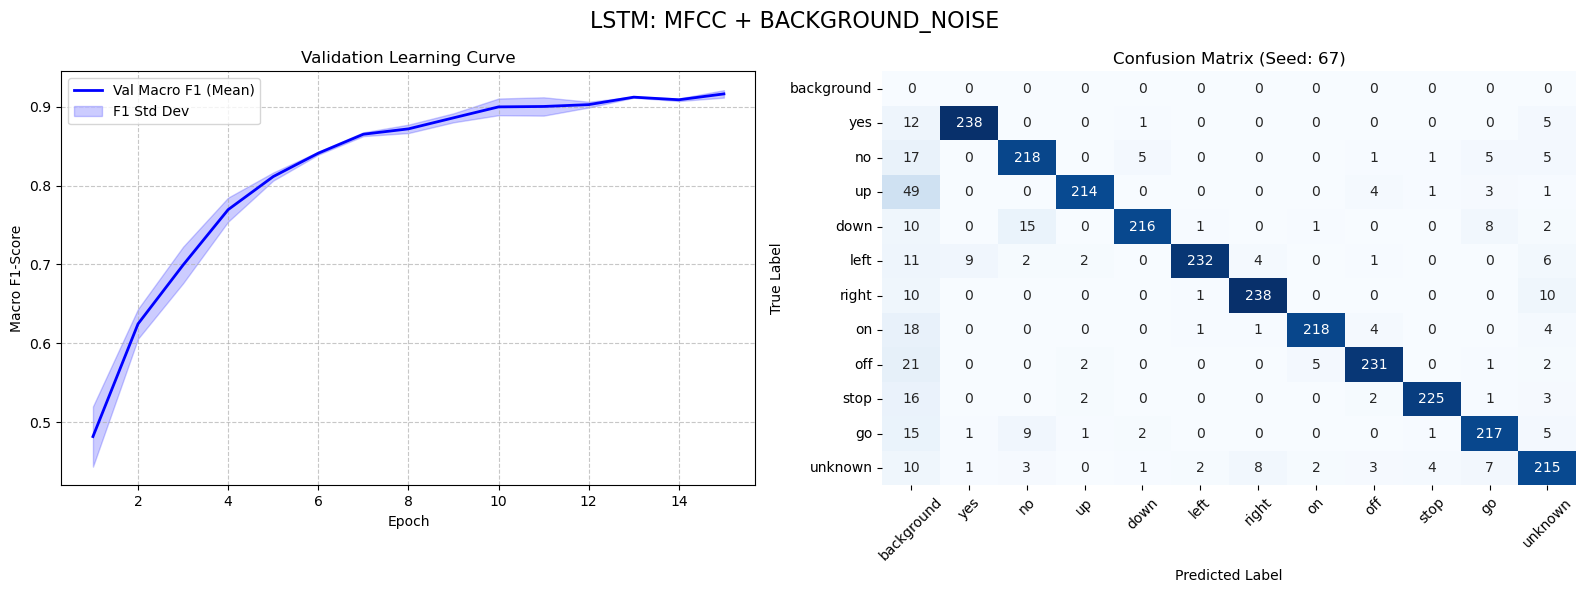


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 3 | Dropout: 0.3 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8104 ± 0.0083
   balanced_acc: 0.8548 ± 0.0077
    overall_acc: 0.8541 ± 0.0077


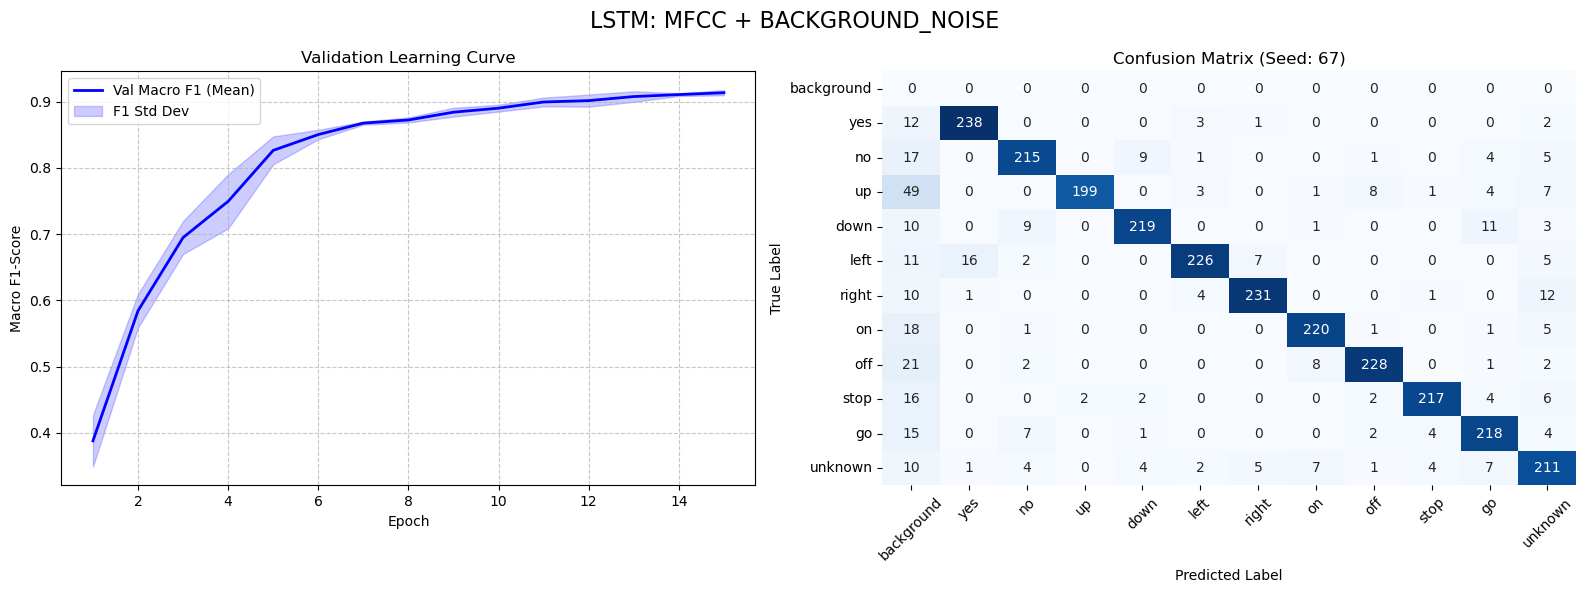


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 3 | Dropout: 0.5 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8096 ± 0.0083
   balanced_acc: 0.8536 ± 0.0098
    overall_acc: 0.8529 ± 0.0099


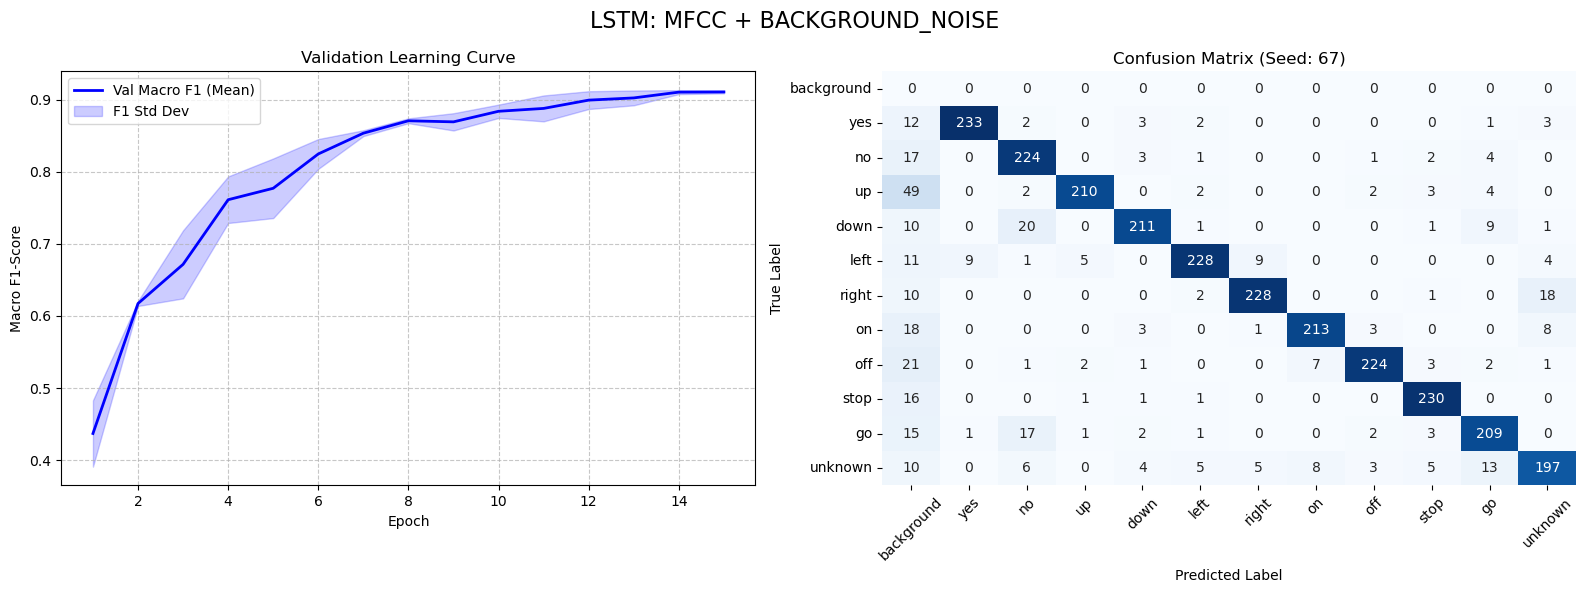

,method,Preprocessing,Augmentation,Layers,Dropout,Learning Rate,macro_f1,balanced_acc,overall_acc
0,two_stage,mfcc,background_noise,3,0.1,0.001,0.8183 ± 0.0095,0.8627 ± 0.0107,0.8621 ± 0.0109
1,two_stage,mfcc,background_noise,3,0.3,0.001,0.8104 ± 0.0083,0.8548 ± 0.0077,0.8541 ± 0.0077
2,two_stage,mfcc,background_noise,3,0.5,0.001,0.8096 ± 0.0083,0.8536 ± 0.0098,0.8529 ± 0.0099


In [4]:
RESULTS_DIR = "../experiments_lstm/phase2/dropout" 

SEEDS = [67, 167, 267] 

dropouts = [0.1,0.3,0.5]

summary_results_dropouts = []

for dropout in dropouts:
    summary = analyze_experiment_pair(
        base_dir=RESULTS_DIR,
        preprocessing="mfcc",
        augmentation="background_noise",
        seeds=SEEDS,
        cm_seed=67,
        layers=3,
        dropout=dropout,
        learning_rate=0.001
    )
    
    if summary is not None:
        summary_results_dropouts.append(summary)
        
summary_df_dropouts = pd.DataFrame(summary_results_dropouts)
summary_df_dropouts

# best layers num = 3, best prep: mfcc,  augmentation: background_noise, best dropout = 0.1 (no imporvement over dropouts 0.3 neither 0.5)


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 3 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8183 ± 0.0095
   balanced_acc: 0.8627 ± 0.0107
    overall_acc: 0.8621 ± 0.0109


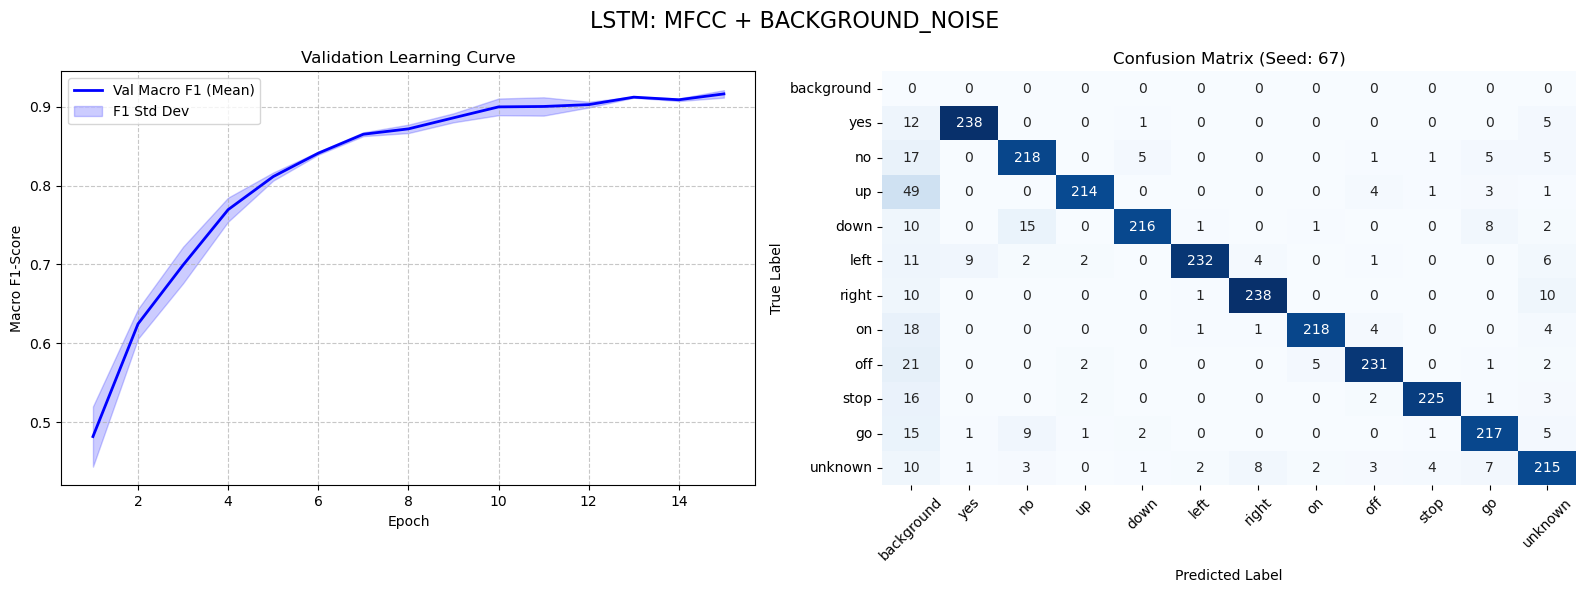


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 3 | Dropout: 0.1 | LR: 0.0001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.6970 ± 0.0074
   balanced_acc: 0.7359 ± 0.0085
    overall_acc: 0.7352 ± 0.0085


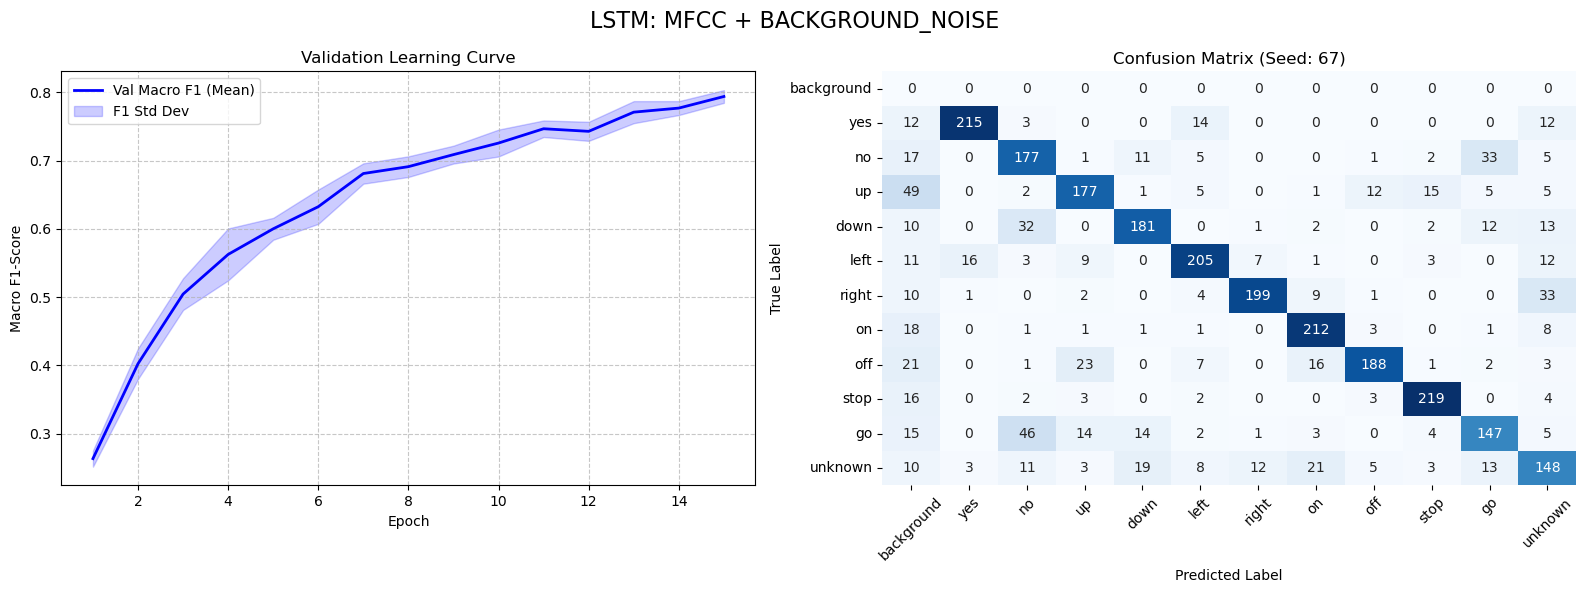


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 3 | Dropout: 0.1 | LR: 1e-05
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.3364 ± 0.0109
   balanced_acc: 0.3842 ± 0.0108
    overall_acc: 0.3828 ± 0.0101


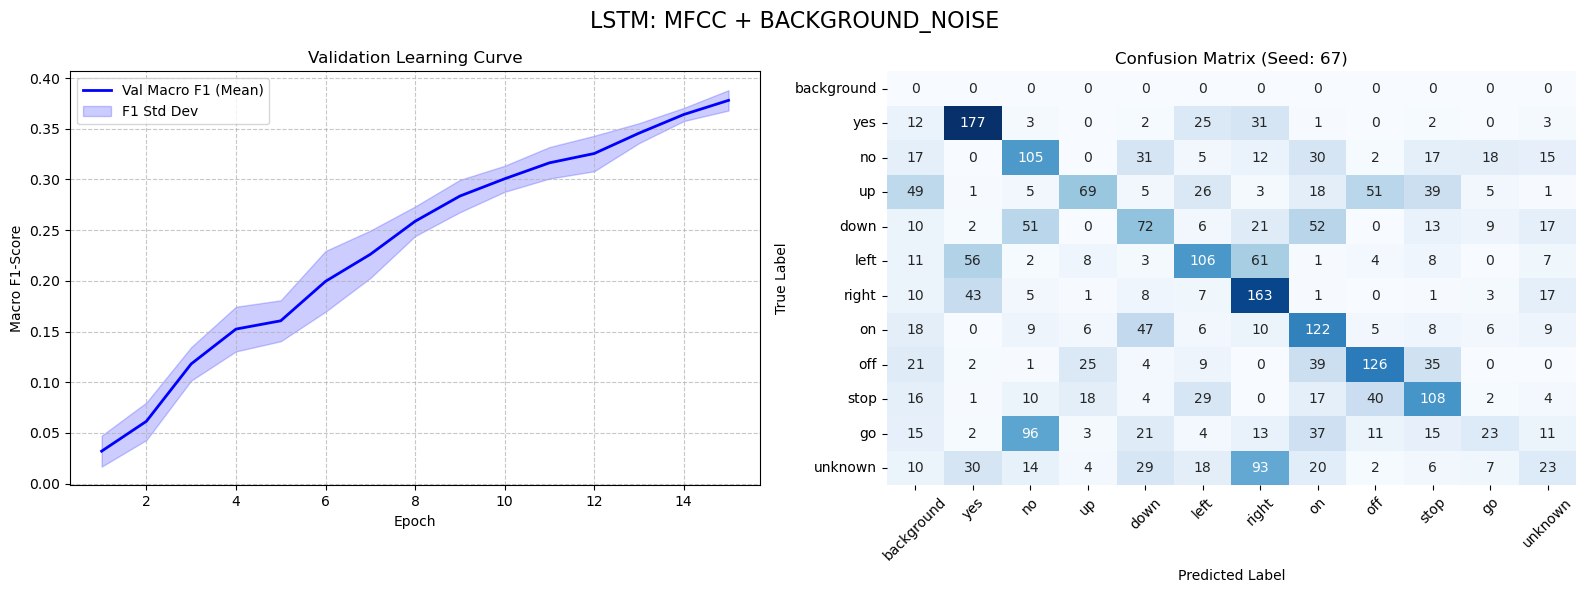

,method,Preprocessing,Augmentation,Layers,Dropout,Learning Rate,macro_f1,balanced_acc,overall_acc
0,two_stage,mfcc,background_noise,3,0.1,0.00100,0.8183 ± 0.0095,0.8627 ± 0.0107,0.8621 ± 0.0109
1,two_stage,mfcc,background_noise,3,0.1,0.00010,0.6970 ± 0.0074,0.7359 ± 0.0085,0.7352 ± 0.0085
2,two_stage,mfcc,background_noise,3,0.1,0.00001,0.3364 ± 0.0109,0.3842 ± 0.0108,0.3828 ± 0.0101


In [5]:
RESULTS_DIR = "../experiments_lstm/phase2/learning_rate" 

SEEDS = [67, 167, 267] 

learning_rates = [0.001,0.0001,1E-5]

summary_results_learning_rates = []

for lr in learning_rates:
    summary = analyze_experiment_pair(
        base_dir=RESULTS_DIR,
        preprocessing="mfcc",
        augmentation="background_noise",
        seeds=SEEDS,
        cm_seed=67,
        layers=3,
        dropout=0.1,
        learning_rate=lr
    )
    
    if summary is not None:
        summary_results_learning_rates.append(summary)
        
summary_df_learning_rates = pd.DataFrame(summary_results_learning_rates)
summary_df_learning_rates

# phase 3


ANALYSIS: Method: two_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 3 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8183 ± 0.0095
   balanced_acc: 0.8627 ± 0.0107
    overall_acc: 0.8621 ± 0.0109


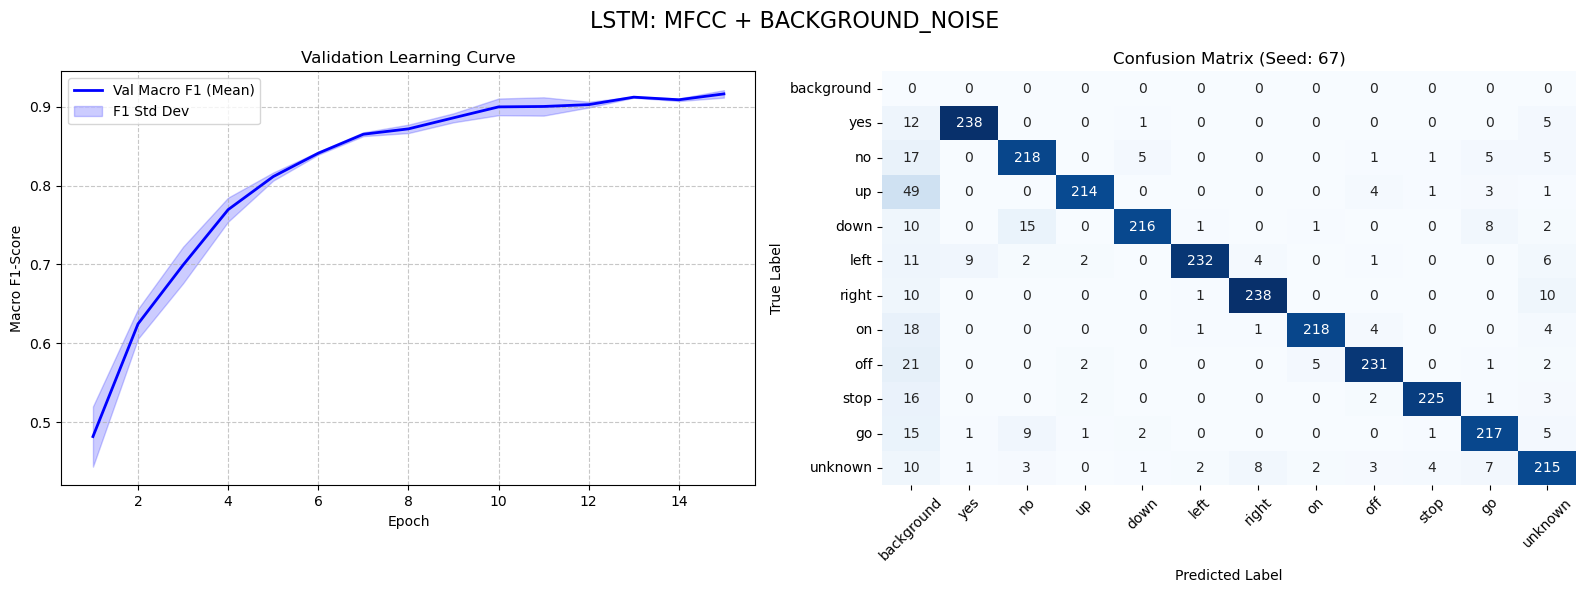


ANALYSIS: Method: single_stage | Preprocessing: mfcc | Augmentation: background_noise | Layers: 3 | Dropout: 0.1 | LR: 0.001
--- FINAL TEST METRICS (12 CLASSES) ---
       macro_f1: 0.8335 ± 0.0544
   balanced_acc: 0.8814 ± 0.0190
    overall_acc: 0.8817 ± 0.0188


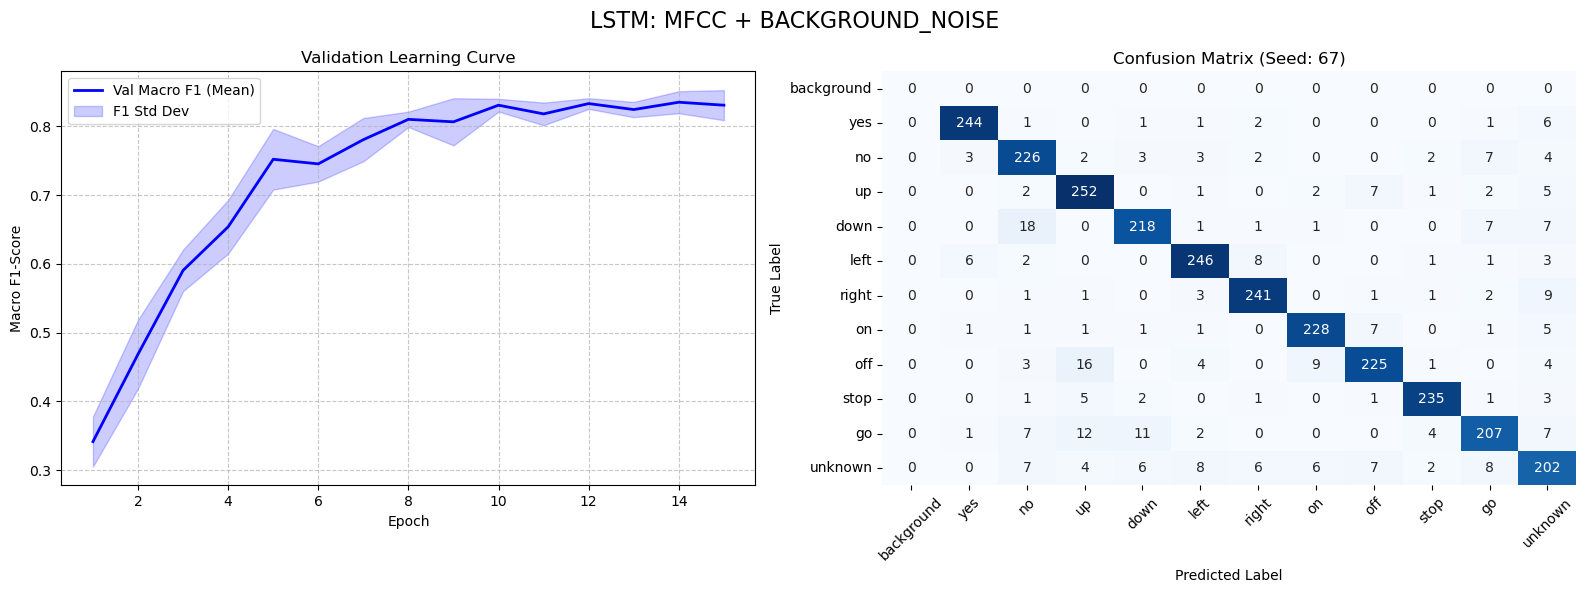

,method,Preprocessing,Augmentation,Layers,Dropout,Learning Rate,macro_f1,balanced_acc,overall_acc
0,two_stage,mfcc,background_noise,3,0.1,0.001,0.8183 ± 0.0095,0.8627 ± 0.0107,0.8621 ± 0.0109
1,single_stage,mfcc,background_noise,3,0.1,0.001,0.8335 ± 0.0544,0.8814 ± 0.0190,0.8817 ± 0.0188


In [7]:
SEEDS = [67, 167, 267] 

methods_dirs = [["two_stage", "../experiments_lstm/phase2/learning_rate"], ["single_stage", "../experiments_lstm/phase3"]]

summary_results_methods = []

for method in methods_dirs:
    summary = analyze_experiment_pair(
        base_dir=method[1],
        preprocessing="mfcc",
        augmentation="background_noise",
        seeds=SEEDS,
        cm_seed=67,
        layers=3,
        dropout=0.1,
        learning_rate=0.001,
        method=method[0]
    )
    
    if summary is not None:
        summary_results_methods.append(summary)
        
summary_df_methods = pd.DataFrame(summary_results_methods)
summary_df_methods